
# Preventing Overfitting with Ridge and Lasso

This notebook demonstrates **overfitting** on a benchmark dataset and how **Ridge** and **Lasso** regularization improve generalization.

**Plan:**
1. Load a benchmark dataset (`sklearn` Diabetes).
2. Create a **high-variance** model using polynomial features (to purposely overfit).
3. Train a baseline **LinearRegression** (no regularization).
4. Train **RidgeCV** and **LassoCV** on the same features.
5. Compare **train vs. test** metrics before and after (RMSE, R²), plot predictions, and inspect coefficient shrinkage.


In [ ]:

import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)


In [ ]:

# 1) Load dataset
data = load_diabetes()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"X shape: {X.shape}, y shape: {y.shape}")
print("Features:", feature_names)


X shape: (442, 10), y shape: (442,)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [ ]:

# 2) Train/validation split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
len(X_train), len(X_test)


(331, 111)


## Create a high-variance setting

We intentionally expand features with a **high-degree polynomial** to make the baseline model overfit.


In [ ]:

poly_degree = 5  # high degree to encourage overfitting

# Pipelines Chains preprocessing + model steps to ensures correct order
# instead of doing the following:
#    X_poly = PolynomialFeatures().fit_transform(X)
#    X_scaled = StandardScaler().fit_transform(X_poly)
#    model.fit(X_scaled, y)

# include_bias=False  --> Prevents adding a constant column of 1s (bias/intercept)
# By default, standardscaler centers features around zero mean and unit variance.
# with_mean=False --> critical here, ❌ Do NOT subtract the mean and ✅ Only scale by standard deviation (z=x/σ​)
# ------------------> Zero stays zero, Sparsity is preserved, Polynomial features remain efficient

baseline_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
    ("scaler", StandardScaler(with_mean=False)),
    ("linreg", LinearRegression())
])

# selects the optimal Ridge regularization strength (λ) using cross-validation
# RidgeCV --> Automatically selects the best α (λ)
# alphas=np.logspace(-4, 4, 50)--> defines the search space for λ:From 10^-4 to 10^4, 50 values, logarithmically spaced
ridge_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
    ("scaler", StandardScaler(with_mean=False)),
    ("ridge", RidgeCV(alphas=np.logspace(-4, 4, 50), cv=KFold(n_splits=5, shuffle=True, random_state=SEED)))
])

# max_iter=500 --> critical in lasso than ridge to Gives the optimizer enough time to converge and Improves coefficient stability
lasso_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
    ("scaler", StandardScaler(with_mean=False)),
    ("lasso", LassoCV(alphas=np.logspace(-4, 1, 50), cv=KFold(n_splits=5, shuffle=True, random_state=SEED), random_state=SEED, max_iter=500))
])


In [ ]:

# 3) Fit baseline (no regularization)
baseline_pipe.fit(X_train, y_train)

# 4) Fit Ridge and Lasso with CV
ridge_pipe.fit(X_train, y_train)
lasso_pipe.fit(X_train, y_train)

ridge_alpha = ridge_pipe.named_steps["ridge"].alpha_
lasso_alpha = lasso_pipe.named_steps["lasso"].alpha_

ridge_alpha, lasso_alpha


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.716e+02, tolerance: 1.586e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.490e+02, tolerance: 1.586e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.579e+02, tolerance: 1.586e

(np.float64(2222.996482526191), np.float64(3.906939937054621))

In [ ]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    rmse_tr = mean_squared_error(y_tr, y_tr_pred)
    rmse_te = mean_squared_error(y_te, y_te_pred)
    r2_tr = r2_score(y_tr, y_tr_pred)
    r2_te = r2_score(y_te, y_te_pred)
    return {
        "Model": name,
        "Train RMSE": rmse_tr,
        "Test RMSE": rmse_te,
        "Train R2": r2_tr,
        "Test R2": r2_te
    }

results = []
results.append(evaluate(baseline_pipe, X_train, y_train, X_test, y_test, f"Linear (deg={poly_degree})"))
results.append(evaluate(ridge_pipe, X_train, y_train, X_test, y_test, f"RidgeCV (alpha={ridge_alpha:.4g})"))
results.append(evaluate(lasso_pipe, X_train, y_train, X_test, y_test, f"LassoCV (alpha={lasso_alpha:.4g})"))

import pandas as pd
pd.DataFrame(results)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear (deg=5),4.429247e-25,74452.228493,1.000000,-12.464088
1,RidgeCV (alpha=2223),2.527067e+03,3572.188027,0.581932,0.353998
2,LassoCV (alpha=3.907),2.592634e+03,2656.314480,0.571084,0.519627



## Predictions vs Ground Truth

If regularization helps, **test predictions** should align better with the diagonal than the overfit baseline.


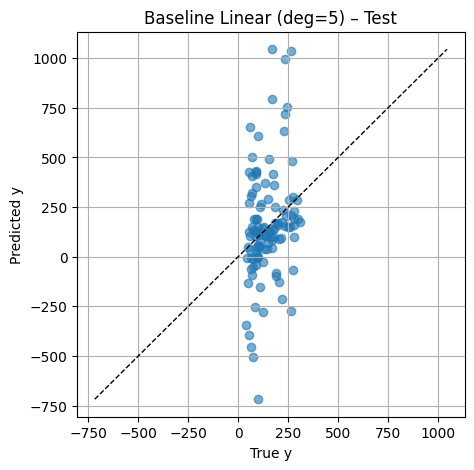

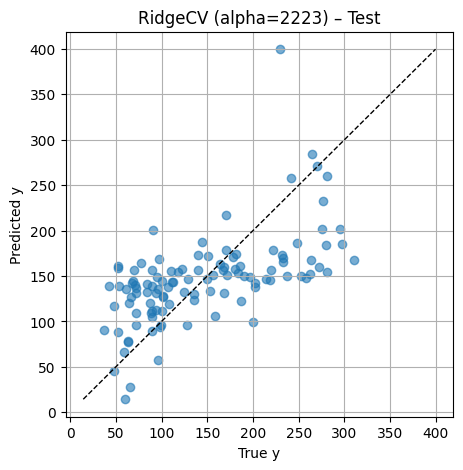

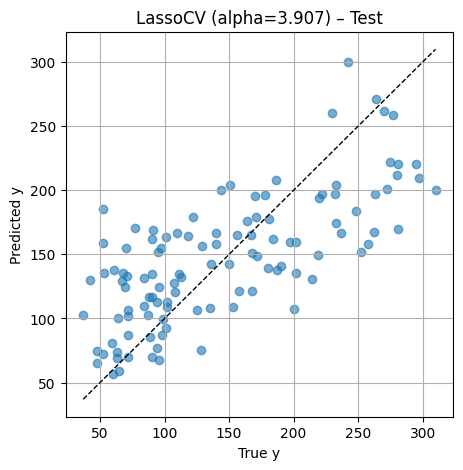

In [ ]:

def plot_predictions(model, X_te, y_te, title):
    y_pred = model.predict(X_te)
    plt.figure(figsize=(5,5))
    plt.scatter(y_te, y_pred, alpha=0.6)
    lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    plt.plot(lims, lims, 'k--', linewidth=1)
    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_predictions(baseline_pipe, X_test, y_test, f"Baseline Linear (deg={poly_degree}) – Test")
plot_predictions(ridge_pipe, X_test, y_test, f"RidgeCV (alpha={ridge_alpha:.4g}) – Test")
plot_predictions(lasso_pipe, X_test, y_test, f"LassoCV (alpha={lasso_alpha:.4g}) – Test")



## Coefficient Shrinkage

Ridge and Lasso **shrink** coefficients (Lasso can set some to **exactly zero**), which reduces variance and improves generalization.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.716e+02, tolerance: 1.586e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.490e+02, tolerance: 1.586e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.579e+02, tolerance: 1.586e

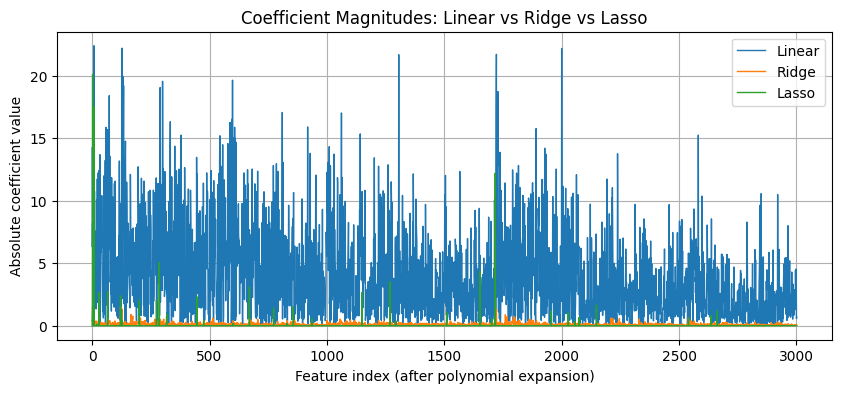

(Linear    4.071217
 Ridge     0.110679
 Lasso     0.036591
 dtype: float64,
 Linear       0
 Ridge        0
 Lasso     2961
 dtype: int64)

In [ ]:

# Extract coefficients after the polynomial expansion to compare magnitudes
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=poly_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)

scaler = StandardScaler(with_mean=False)
X_train_poly_scaled = scaler.fit_transform(X_train_poly)

lin = LinearRegression().fit(X_train_poly_scaled, y_train)
ridge = RidgeCV(alphas=np.logspace(-4, 4, 50), cv=KFold(n_splits=5, shuffle=True, random_state=SEED)).fit(X_train_poly_scaled, y_train)
lasso = LassoCV(alphas=np.logspace(-4, 1, 50), cv=KFold(n_splits=5, shuffle=True, random_state=SEED), random_state=SEED, max_iter=500).fit(X_train_poly_scaled, y_train)

import pandas as pd
coefs = pd.DataFrame({
    "Linear": lin.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

plt.figure(figsize=(10,4))
plt.plot(np.abs(coefs["Linear"].values), label="Linear", linewidth=1)
plt.plot(np.abs(coefs["Ridge"].values), label="Ridge", linewidth=1)
plt.plot(np.abs(coefs["Lasso"].values), label="Lasso", linewidth=1)
plt.xlabel("Feature index (after polynomial expansion)")
plt.ylabel("Absolute coefficient value")
plt.title("Coefficient Magnitudes: Linear vs Ridge vs Lasso")
plt.legend()
plt.grid(True)
plt.show()

coefs.abs().mean(), (coefs == 0).sum()



### Takeaways
- Without regularization, a high-degree polynomial **overfits** (low train error, poorer test error).
- **Ridge** and **Lasso** penalize large coefficients, improving **test** performance.
- **Ridge** shrinks many coefficients; **Lasso** can drive some to **exactly zero** (feature selection effect).
